In [229]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# We begin by first import the essential Python libraries for preprocessing the dataset, building, testing/training, evaluating, and visualizing the Supprt Vector Machines model.

In [230]:
df = pd.read_csv("C:/Users/rotim/Downloads/Maternal Health Risk Data Set.csv")

# We then import the data set into our Python journal from the originating csv file. This will serve as our dataframe.
# This data set is contains maternal patient data amassed from an array of hospitals and clinic within the rural regions of Bangladesh.

In [371]:
# PREPROCESSING & EXPLORATORY DATA ANALYSIS
# Exploratory data analysis is performed in order to understand the data types, the various features that are included, the format and arrangmenet of the data, as well as the distribution of data points.

In [232]:
df.head(20)

# To understand the features, formatting, and data types that comprise the data set, we review the first 20 rows. 
# The columns of the data set consists of six features (or attributes), which are age, systolic blood pressure (SystolicBP), diastolic blood pressure (DiastolicBP), blood sugar (BS), body temperature (BodyTemp), and heart rate (HeartRate). These will serve as the independent (x) variables in our classification model. Additionally, the data points recorded within the feature columns are numerical.
# The right-most column, RiskLevel, will serve as the target (y) variable that our classfication model will predict. The data points within this target variable column are categorical, which the unique data points of "low risk", "mid risk", and "high risk" representing the class labels for our classification model.
# Each row under below the column titles represents the health records of a unique maternal patient.

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.00,98.0,86,high risk
1,35,140,90,13.00,98.0,70,high risk
2,29,90,70,8.00,100.0,80,high risk
3,30,140,85,7.00,98.0,70,high risk
4,35,120,60,6.10,98.0,76,low risk
5,23,140,80,7.01,98.0,70,high risk
6,23,130,70,7.01,98.0,78,mid risk
7,35,85,60,11.00,102.0,86,high risk
8,32,120,90,6.90,98.0,70,mid risk
9,42,130,80,18.00,98.0,70,high risk


In [233]:
df.shape

# By checking the shape of the data set, we can determine that there are 1014 rows, or distinct patient records, as well as 7 variables.
# 6 of these variables are features, and 1 of these variables is the output variable.

(1014, 7)

In [234]:
df.info()

# The summary of the data frame indicates that the first 6 columns contain numerical data points. To be more precise, the feature columns of Age, Systolic BP, Diastolic BP, and HeartRate list data points as whole numbers, whereas the feature columns of Blood Sugar (BS) and BodyTemp list data points as real numbers with decimals.
# The output varible of RiskLevel has data listed as objects. We will need to convert the unique data values to numerical categories to use within the claissfication model.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [235]:
df.describe()

# To review Summary Statistics in order to understand the spread of the data points

# The ages recorded within the maternal patient records range from 10 to 70 years of age, with an average patient age of 29.8 years.
# Systolic BP ranges from 70 to 160, and Diastolic BP ranges from 49 to 100.
# BodyTemp ranges from 98 to 103 degrees Fahrenheit, with an average body temperature of 98.7.
# HeartRate ranges from 7 to 90 beats per minute. The minimum data point of 7 beat per minute is an extreme outlier as the 25th percentile (or first quartile) for the data range is 70 beats per minute.

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.00000,1014.00000,1014.00000,1014.00000,1014.00000,1014.00000
mean,29.87179,113.19822,76.46055,8.72599,98.66509,74.30178
std,13.47439,18.40391,13.88580,3.29353,1.37138,8.08870
min,10.00000,70.00000,49.00000,6.00000,98.00000,7.00000
25%,19.00000,100.00000,65.00000,6.90000,98.00000,70.00000
50%,26.00000,120.00000,80.00000,7.50000,98.00000,76.00000
75%,39.00000,120.00000,90.00000,8.00000,98.00000,80.00000
max,70.00000,160.00000,100.00000,19.00000,103.00000,90.00000


In [236]:
df.isnull().sum()

# To check for missing values

# There are no missing values within the data frame.

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

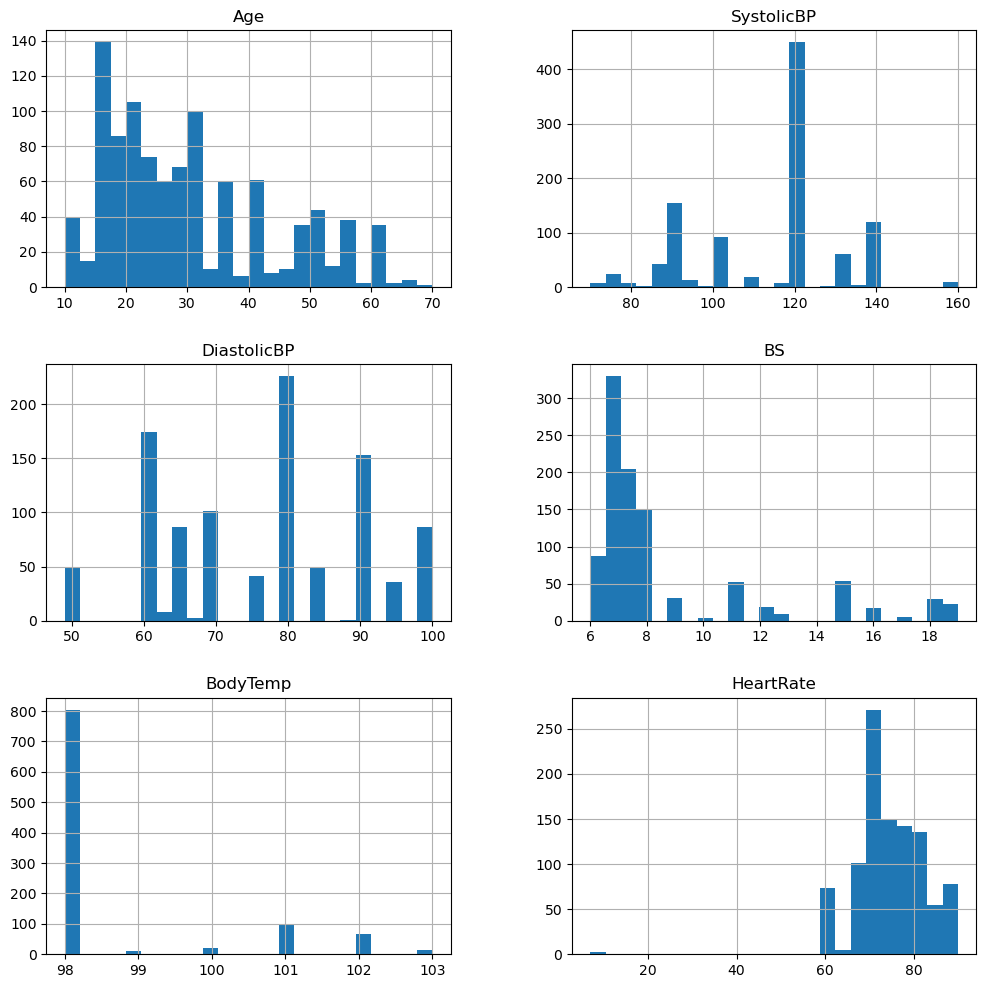

In [237]:
df.hist(figsize=(12,12),bins=24)
plt.show()

# To plot histograms for each feature in order to examine their distributions

# As previously surmised, the data of 7 beats per minute under Heart Rate is an outlier. This may be the result of a data entry error. In order to address this, we will impute the outlier and replace its value with the median value under Heart Rate.

In [238]:
df.nunique()

# To review the quantity of unique data point values under each column within the data frame

# The Age and Blood Sugar features contain the highest quantity of unique data point values.

Age            50
SystolicBP     19
DiastolicBP    16
BS             29
BodyTemp        8
HeartRate      16
RiskLevel       3
dtype: int64

In [239]:
# DATA CLEANING & PREPROCESSING

In [240]:
from sklearn.preprocessing import LabelEncoder

encoder = {"low risk": 0, "mid risk": 1, "high risk": 2}
df['RiskLevel'] = df['RiskLevel'].map(encoder)

# To convert the categorical labels of "low risk", "mid risk", and "high risk" under Risk Level to numerical data values, we employ a label dictionary to ensure that low risk equates to '0', mid risk equates to '1', and high risk equates to '2'.

In [241]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Age'] = scaler.fit_transform(df[['Age']])
df['SystolicBP'] = scaler.fit_transform(df[['SystolicBP']])
df['DiastolicBP'] = scaler.fit_transform(df[['DiastolicBP']])
df['BS'] = scaler.fit_transform(df[['BS']])
df['BodyTemp'] = scaler.fit_transform(df[['BodyTemp']])
df['HeartRate'] = scaler.fit_transform(df[['HeartRate']])

# We normalize the data under the Age, Systolic BP, Diastolic BP, Blood Sugar, BodyTemp, and Heart Rate feature columns using StandardScaler. This will ensure that features with data values of widely differing magnitudes are adjusted to a common scale so that features with values of higher magnitudes do not have a disproportionate impact on the classification model.
# StandardScaler will ensure that data under these selected features has a mean of zero and a standard deviation of 1.

In [242]:
Q3_HR = df['HeartRate'].quantile(0.75)
Q1_HR = df['HeartRate'].quantile(0.25)
IQR = Q3_HR - Q1_HR


low_HR = Q1_HR - 1.5 * IQR
high_HR = Q3_HR + 1.5 * IQR


median_HR = df['HeartRate'].median()
df['HeartRate'] = df['HeartRate'].apply(lambda x: median_HR if x < low_HR or x > high_HR else x)


# In order to convert the outliers under Heart Rate to the median of the data range, we calculate the first and third quartiles as well as the interquartile range.
# We multiply the interquartile range value by 1.5, add the product to the third quartile, and subtract the product from the first quartile in order to derive the lower and upper thresholds for outliers.
# We then convert any data point beyond the lower and upper thresholds to the median of the Heart Rate data range.

In [243]:
corr_matrix = df.corr(method='pearson')
print(corr_matrix)

                 Age  SystolicBP  DiastolicBP       BS  BodyTemp  HeartRate  \
Age          1.00000     0.41605      0.39803  0.47328  -0.25532    0.06723   
SystolicBP   0.41605     1.00000      0.78701  0.42517  -0.28662   -0.01817   
DiastolicBP  0.39803     0.78701      1.00000  0.42382  -0.25754   -0.05158   
BS           0.47328     0.42517      0.42382  1.00000  -0.10349    0.14923   
BodyTemp    -0.25532    -0.28662     -0.25754 -0.10349   1.00000    0.09752   
HeartRate    0.06723    -0.01817     -0.05158  0.14923   0.09752    1.00000   
RiskLevel    0.26723     0.39647      0.34665  0.56994   0.16398    0.18967   

             RiskLevel  
Age            0.26723  
SystolicBP     0.39647  
DiastolicBP    0.34665  
BS             0.56994  
BodyTemp       0.16398  
HeartRate      0.18967  
RiskLevel      1.00000  


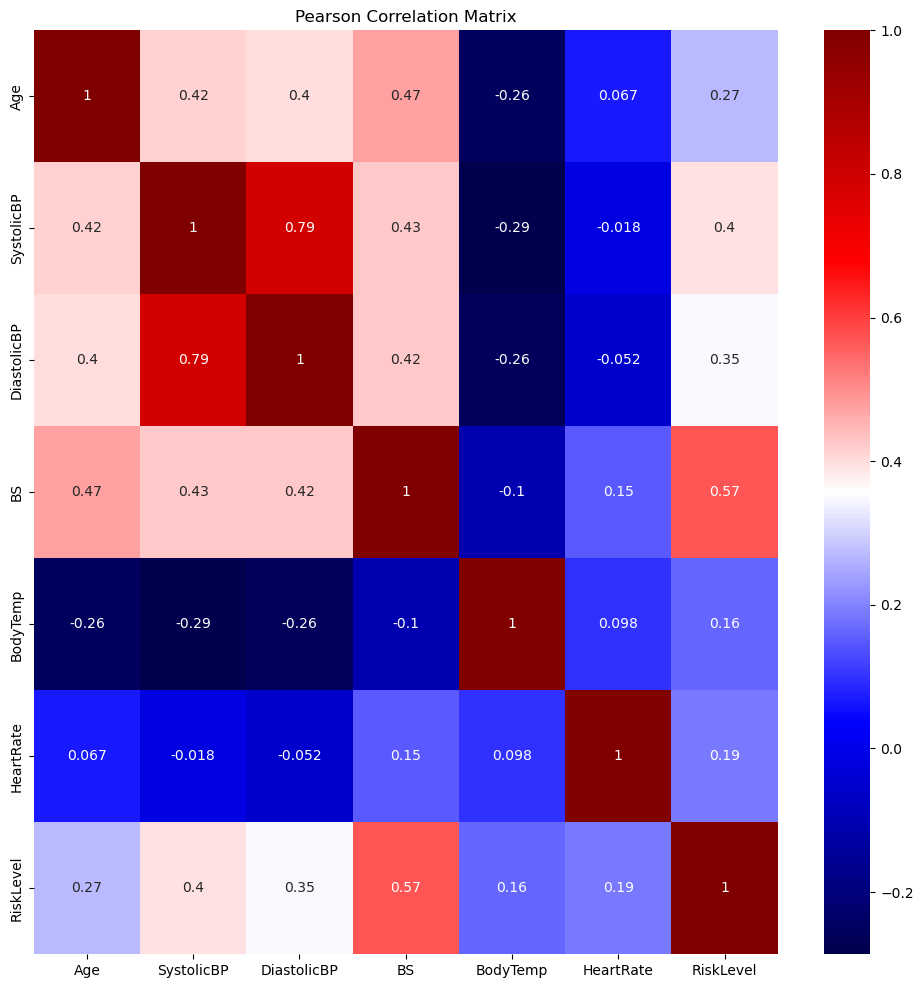

In [244]:
plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=True, cmap='seismic')
plt.title('Pearson Correlation Matrix')
plt.show()

# We generate a Pearson correlation matrix in order to review the correlation coefficients between all of the features within the data frame.
# Diastolic BP and Systolic BP have a relatively high correlation coefficient, which indicates that there is a strong linear relationship between the two features and potential multicollinearity.
# In an effort to address this indication of multicollinearity, we will apply regularization and Principal Component Analysis to the model.

In [246]:
df.head(20)

# We preview the revised data frame in order to ensure that all of the features are scaled appropriately, and the Risk Level categorical labels have been properly encoded.

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,-0.36174,0.91340,0.25502,1.90589,-0.48522,1.44696,2
1,0.38078,1.45703,0.97554,1.29834,-0.48522,-0.53209,2
2,-0.06473,-1.26113,-0.46549,-0.22054,0.97388,0.70481,2
3,0.00952,1.45703,0.61528,-0.52431,-0.48522,-0.53209,2
4,0.38078,0.36977,-1.18601,-0.79771,-0.48522,0.21005,0
5,-0.51024,1.45703,0.25502,-0.52127,-0.48522,-0.53209,2
6,-0.51024,0.91340,-0.46549,-0.52127,-0.48522,0.45743,1
7,0.38078,-1.53294,-1.18601,0.69079,2.43298,1.44696,2
8,0.15802,0.36977,0.97554,-0.55469,-0.48522,-0.53209,1
9,0.90054,0.91340,0.25502,2.81722,-0.48522,-0.53209,2


In [247]:
# SPLIT DATA -- TRAINING & TESTING

In [248]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Before splitting the data set into training and testing subsets, we define the input (X) variable and the target (y) variable.
# The input 'X' will comprise of all features. Using 'iloc' in Pandas, we select all columns within the data frame except for the last column on the right.
# The target 'y' will comprise of the Risk Level column, which is the last column on the right. Using 'iloc' in Pandas, we select solely the last column on the right side of the data frame.

In [249]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# For the purpose of training and testing the model, we will use 30% of the data as the test subset and 70% of the data as the training subset.
# The 'random_state' parameter is set to a random number, '42' in this case, so that the random data points allocated to the training and testing subsets can be reproduced each time the code is excuted.

In [250]:
# SUPPORT VECTOR CLASSIFIER

In [317]:
SVM = SVC(kernel="linear",C=1, random_state=42)
SVM.fit(X_train, y_train)

# We implement the Support Vector Classifier to build our first classification model.
# The default setting of '1' is used for the regularization paramter 'C', the linear kernel is applied, and 'random_state' is set to '42' for the sake of reproducibility.
# The model is fitted or trained using the training subset.

SVC(C=1, kernel='linear', random_state=42)

In [318]:
y_pred = SVM.predict(X_test)

# Following the training of the model, we test the model by using it to predict class labels for the testing subset.

In [319]:
accuracy = accuracy_score(y_test, y_pred)
print(f" Support Vector Classifier Accuracy: {accuracy * 100:.2f}%")

 Support Vector Classifier Accuracy: 61.31%


In [320]:
print("Support Vector Classification Report:")
print(classification_report(y_test, y_pred))

# The model displays difficulty correctly predicting members of the low risk class as suggested by the low precision value. 
# The model seems to experience more of a challenge in identifying and correctly predicting members of the mid risk class. This is supported by the relatively low recall, relatively low precision, and overall low F1-score measured. 
# The model appears to be most effective at identifying and correctly predicting members of the high risk class.


Support Vector Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.92      0.70       117
           1       0.61      0.22      0.33       112
           2       0.75      0.71      0.73        76

    accuracy                           0.61       305
   macro avg       0.64      0.62      0.59       305
weighted avg       0.63      0.61      0.57       305



In [255]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C':[0.5,0.1,1,10,100],
              'kernel':['rbf','linear']}

optimal_params = GridSearchCV(SVC(), param_grid, cv = 3, scoring='accuracy')
optimal_params.fit(X_train, y_train)


# In an effort to enhance the predictive performance of the classification model, we employ GridSearchCV() to identify the optimal parameters, specifically the regularization paramenter 'C' and kernel, for the Support Vector Classifier.

GridSearchCV(cv=3, estimator=SVC(),
             param_grid={'C': [0.5, 0.1, 1, 10, 100],
                         'kernel': ['rbf', 'linear']},
             scoring='accuracy')

In [256]:
optimal_params.best_params_

# We print the 'best parameters' selected by GridSearchCV, which are as follows:

{'C': 100, 'kernel': 'rbf'}

In [334]:
# SUPPORT VECTOR CLASSIFIER - OPTIMIZED

In [364]:
SVM = SVC(random_state = 42, C=100, kernel='rbf')
SVM.fit(X_train, y_train)

# We fit or train the model, using the 'best parameters'.

SVC(C=100, random_state=42)

In [365]:
y_pred = SVM.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'(Optimized) Support Vector Classifier Accuracy: {accuracy:.2%}')

# We use the model, which has been trained under the optimal parameters, to make class label predictions for the test subset.
# The accuracy score has improved from 61.31% to 66.89%.

(Optimized) Support Vector Classifier Accuracy: 66.89%


In [366]:
print("(Optimized) Support Vector Classification Report:")
print(classification_report(y_test, y_pred))

# After training the Support Vector classifier model under the optimal parameters determined by GridSearchCV, there were overall improvements to the model's predictive performance. 
# With respect to the low risk class (class 0), precision improved from 0.56 to 0.64, which means that the model's ability to make correct predictions for this class has increased albeit slightly.
# With respect to the mid risk class (class 1), both precision and recall improved resulting in the F1-score increasing significantly from 0.33 to 0.44. Thus, the model's ability to make correct predictions for this class and identify instances of this class has increased.
# With respect to the high risk class (class 2), precision improved, but recall remained unchanged, resulting in a slight increase in the F1-score.
# Despite these improvements, the model still displays some difficulty with making correct predictions for the low risk class as indicated by the low precision. The model displays even greater difficulty in identifying and correctly predicting members of the mid risk class. 
# The model appears to be most effective at identifying and correctly predicting members of the high risk class.


(Optimized) Support Vector Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.74      0.69       117
           1       0.61      0.51      0.56       112
           2       0.80      0.79      0.79        76

    accuracy                           0.67       305
   macro avg       0.68      0.68      0.68       305
weighted avg       0.67      0.67      0.67       305



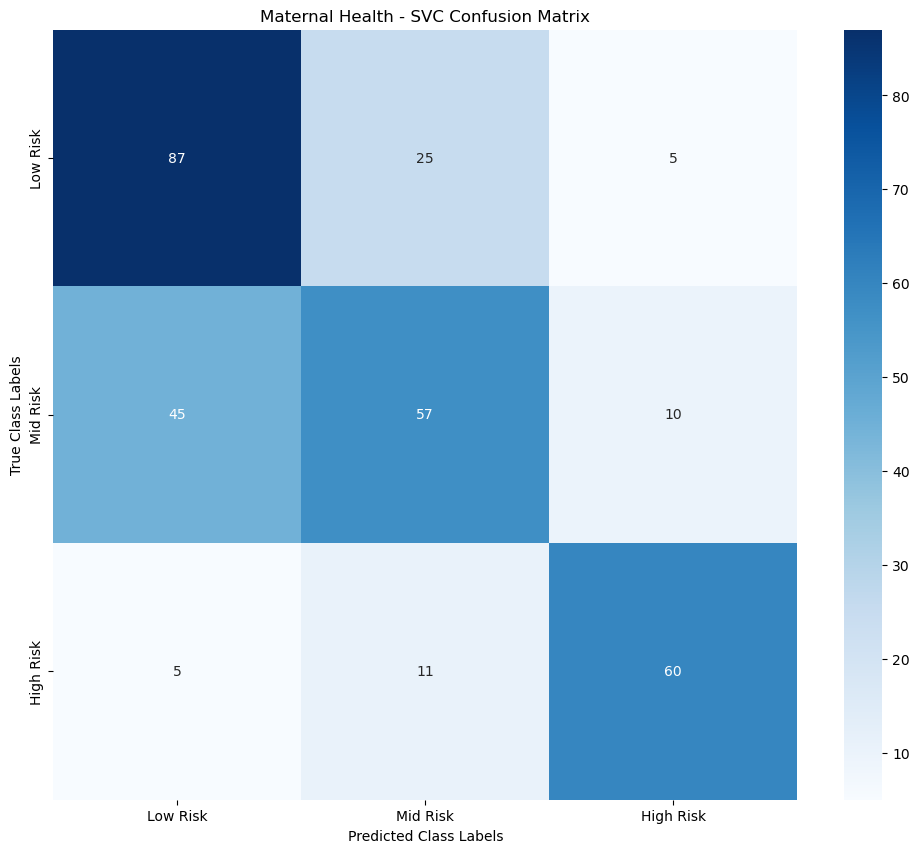

In [367]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', cbar=True, xticklabels=["Low Risk", "Mid Risk", "High Risk"], yticklabels=["Low Risk", "Mid Risk", "High Risk"])

plt.title('Maternal Health - SVC Confusion Matrix')
plt.xlabel('Predicted Class Labels')
plt.ylabel('True Class Labels')
plt.show()

In [278]:
from sklearn.inspection import DecisionBoundaryDisplay

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

SVM = SVC(random_state = 42, C=100, kernel='rbf')
SVM.fit(X_train_pca, y_train)

# The dimensionality of the data set is reduced to two principal components in order to make the class predictions and decision boundaries easier to visualize.

SVC(C=100, random_state=42)

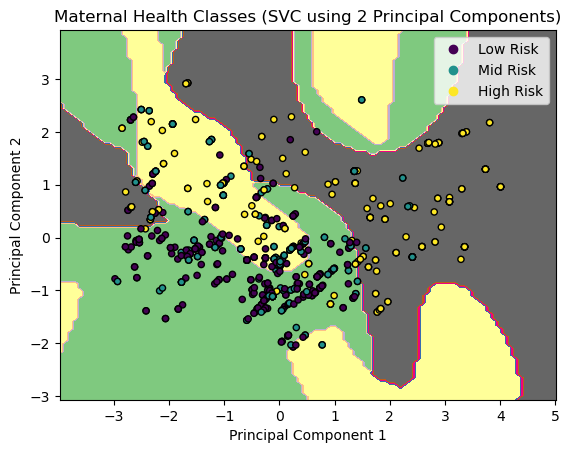

In [279]:
disp = DecisionBoundaryDisplay.from_estimator(SVM, X_train_pca, response_method="predict", cmap="Accent", xlabel = "Principal Component 1", ylabel = "Principal Component 2")

scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolor="k", cmap="viridis", s=20)
plt.legend(handles=scatter.legend_elements()[0], labels=["Low Risk", "Mid Risk", "High Risk"])
plt.title("Maternal Health Classes (SVC using 2 Principal Components)")
plt.show()


# The data points visualized within this scatter plot are class predictions for the PCA-reduced training subset.
# The dark gray area represents the high risk predictions.
# The green area represents the low risk predictions due to a majority of low risk data points plotted in this area. However, there appears to be an overlap of classes since there are also a substantial number of high risk and mid risk data points within this area.
# The yellow area represents the mid risk predictions due to a majority of mid risk data points plotted in this area. However, there appears to be an overlap of classes due to the significant presence of high risk data points within this area.

In [292]:
from mpl_toolkits.mplot3d import Axes3D

pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train)

SVM = SVC(random_state=42, C=100, kernel='rbf')
SVM.fit(X_train_pca, y_train)


SVC(C=100, random_state=42)

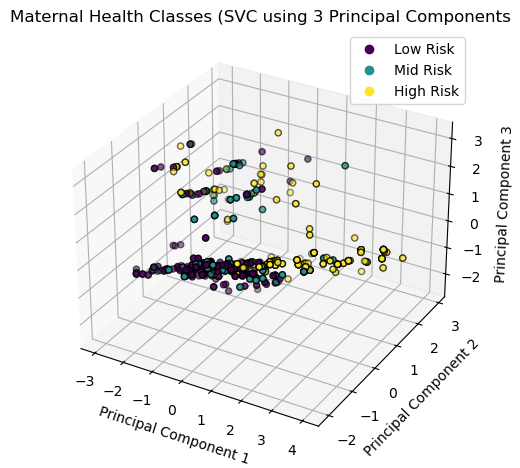

In [293]:
fig = plt.figure(figsize=(12, 12))
disp = fig.add_subplot(121, projection='3d')

scatter = disp.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2], c=y_train, cmap="viridis", edgecolor="k", s=20)

disp.set_xlabel("Principal Component 1")
disp.set_ylabel("Principal Component 2")
disp.set_zlabel("Principal Component 3")

disp.legend(handles=scatter.legend_elements()[0], labels=["Low Risk", "Mid Risk", "High Risk"])

plt.title("Maternal Health Classes (SVC using 3 Principal Components")
plt.show()

# This 3-dimensional scatter plot of the class predictions shows a clearly discernible region of high risk data points.
# It is much harder to define or interpret a clear boundary between the low risk and mid risk data points as there is overlap between the two classes.
# The extensive overlapping of low risk and mid risk data points can be explained by the low precision measured for the low risk and mid risk classes even after the model's parameters were optimized.

In [294]:
# RANDOM FOREST CLASSIFIER

In [347]:
from sklearn.ensemble import RandomForestClassifier

ran_forest = RandomForestClassifier(n_estimators=100, random_state=42)
ran_forest.fit(X_train, y_train)
y_pred = ran_forest.predict(X_test)

# We will now build a Random Forest Classifier model and evaluate its predictive performance after training it on our training subset.
# This Random Forest model will be comprised of 100 trees as indicated by the n_estimators parameter, which has been set to 100.

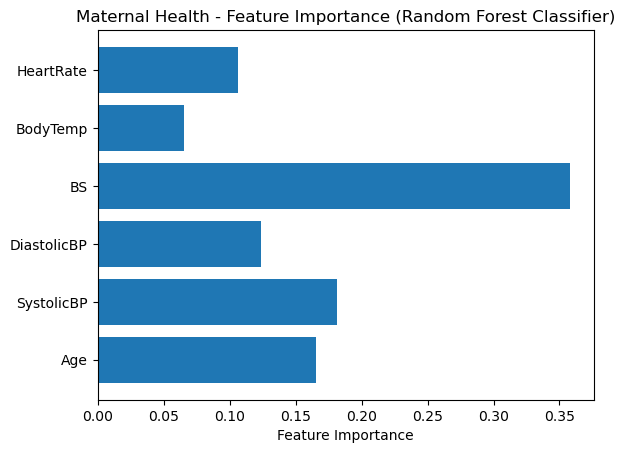

In [304]:
importantfeatures = ran_forest.feature_importances_

plt.barh(X.columns, importantfeatures)
plt.xlabel('Feature Importance')
plt.title('Maternal Health - Feature Importance (Random Forest Classifier)')
plt.show()

# This bar plot of feature importances illustrates the features that are most significant and important in the Random Forest Classifier model's predictions.
# The Blood Sugar feature is of chief importance, followed by the Systolic BP and Age features.


In [348]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Random Forest Accuracy: {accuracy:.2%}')

# At 80.66%, the accuracy score for the Random Forest Classifier model is much higher than the optimized Support Vector Classifier model.

Random Forest Accuracy: 80.66%


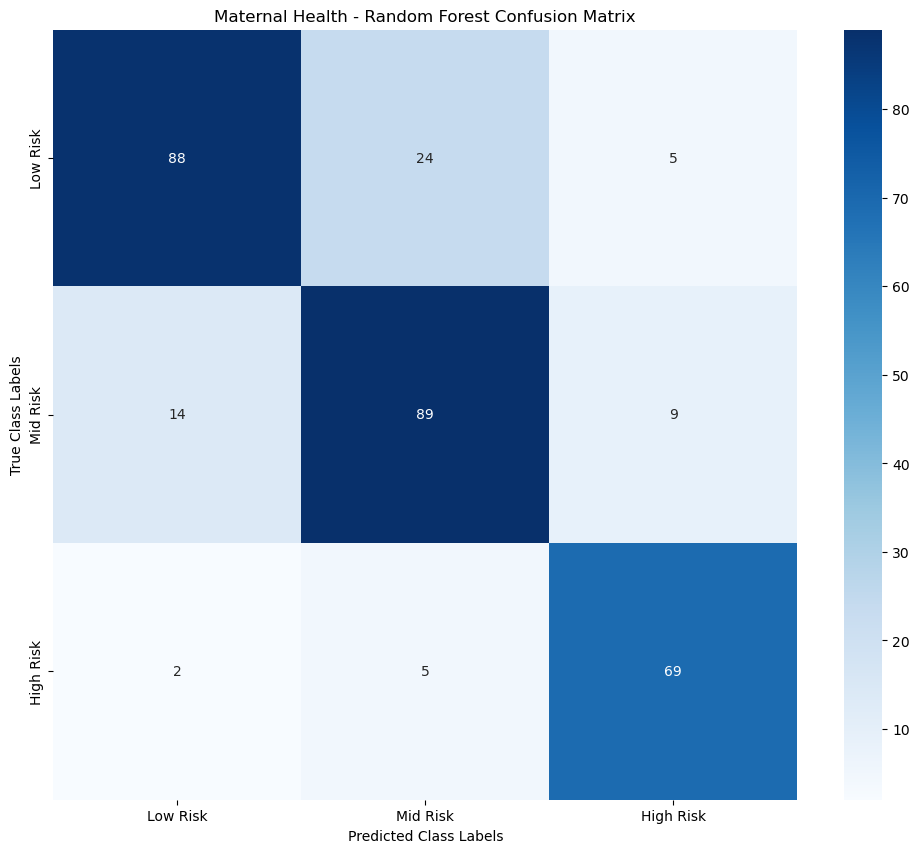

In [298]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', cbar=True, xticklabels=["Low Risk", "Mid Risk", "High Risk"], yticklabels=["Low Risk", "Mid Risk", "High Risk"])

plt.title('Maternal Health - Random Forest Confusion Matrix')
plt.xlabel('Predicted Class Labels')
plt.ylabel('True Class Labels')
plt.show()

# The confusion matrix produced for the Random Forest Classifier model highlights the high accuracy score noted, with a high percentage of the predicted class labels matching the true class.

In [327]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

# Similar to the optimized Support Vector Classifier model, the Random Forest Classifier model appears to be most effective at identifying and correctly predicting for the high risk class (class 2). The recall and F1-score for the high risk are greater than those measured for the other two classes.
# Nevertheless, the model does display relative effectiveness at identifying and correctly predicting members of the low and mid risk classes, with the F1 scores measured  for these classes being considerably higher than those measured while testing the optimized Support Vector Classifier model.

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.75      0.80       117
           1       0.75      0.79      0.77       112
           2       0.83      0.91      0.87        76

    accuracy                           0.81       305
   macro avg       0.81      0.82      0.81       305
weighted avg       0.81      0.81      0.81       305



In [308]:
# EXTREME GRADIENT BOOSTING (XGB)

In [313]:
pip install xgboost

   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/56.8 MB 1.4 MB/s eta 0:00:41
    --------------------------------------- 1.0/56.8 MB 1.7 MB/s eta 0:00:33
    --------------------------------------- 1.0/56.8 MB 1.7 MB/s eta 0:00:33
   - -------------------------------------- 2.1/56.8 MB 2.2 MB/s eta 0:00:25
   - -------------------------------------- 2.4/56.8 MB 1.9 MB/s eta 0:00:28
   -- ------------------------------------- 2.9/56.8 MB 2.1 MB/s eta 0:00:26
   -- ------------------------------------- 3.7/56.8 MB 2.4 MB/s eta 0:00:22
   -- ------------------------------------- 3.9/56.8 MB 2.2 MB/s eta 0:00:24
   --- ------------------------------------ 4.7/56.8 MB 2.4 MB/s eta 0:00:22
   --- ------------------------------------ 5.0/56.8 MB 2.4 MB/s eta 0:00:22
   --- -------------

In [354]:
from xgboost import XGBClassifier 

boost = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1,objective='reg:logistic')
boost.fit(X_train, y_train)
y_pred = boost.predict(X_test)

# We will now build a Extreme Gradient Boosting (XGBoost) Classifier model and evaluate its predictive performance after training it on our training subset.
# This XGBoost Classifier model will be comprised of 100 trees as indicated by the n_estimators parameter, which has been set to 100.
# The learning rate of 0.1 indicates the step size of the model as it learns and reduces errors.
# The max_depth parameter is set to '3'. Therefore, each individual tree will have a maximum of 3 levels.
# The objective parameter dictates the loss function the model will employ. This parameter has been set to 'reg:logistic' as the model will be tasked with making predictions for a classification problem.

In [355]:
accuracy = accuracy_score(y_test, y_pred)
print(f'XGBoost Classifier Accuracy: {accuracy:.2%}')

# At 73.44%, the accuracy score of the XGBoost Classifier model is higher than that of the optimized Support Vector Classifier but less than that of the Random Forest Classifier.

XGBoost Classifier Accuracy: 73.44%


In [356]:
param_grid = {'n_estimators':[50,100,200,300,400],
              'learning_rate':[0.1,0.25,0.5]}

optimal_params = GridSearchCV(XGBClassifier(), param_grid, cv = 3, scoring='accuracy')
optimal_params.fit(X_train, y_train)


# In an effort to enhance the predictive performance of the XGBoost classification model, we employ GridSearchCV() to identify the optimal parameters, specifically the n_estimators and learning_rate parameters.

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.1, 0.25, 0.5],
                         'n_estimators': [50, 100, 200, 300, 400]},
             scoring='accuracy')

In [357]:
optimal_params.best_params_

{'learning_rate': 0.5, 'n_estimators': 300}

In [358]:
# EXTREME GRADIENT BOOSTING (XGB) -- OPTIMIZED

In [359]:
boost = XGBClassifier(n_estimators=600, max_depth=3, learning_rate=0.5,objective='reg:logistic')
boost.fit(X_train, y_train)

# We fit or train the optimized XGBoost model, using the 'best parameters' of ['learning_rate': 0.5, 'n_estimators': 300].

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.5, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=600,
              n_jobs=None, num_parallel_tree=None, ...)

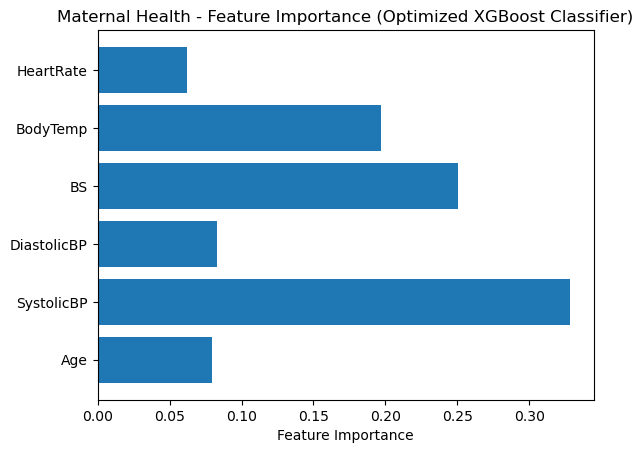

In [361]:
importantfeatures = boost.feature_importances_

plt.barh(X.columns, importantfeatures)
plt.xlabel('Feature Importance')
plt.title('Maternal Health - Feature Importance (Optimized XGBoost Classifier)')
plt.show()

# This bar plot of feature importances illustrates the features that are most significant and important in the XGBoost Classifier model's predictions.
# The Systolic BP feature is of primary importance, followed by the Blood Sugar and Body Temperature features.

In [360]:
y_pred = boost.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Optimized XGBoost Classifier Accuracy: {accuracy:.2%}')

# After being trained under the optimal parameters determined by GridSearchCV, the optimized XGBoost Classifier model shows an improved accuracy score.

Optimized XGBoost Classifier Accuracy: 80.98%


In [363]:
print("Optimized XGBoost Classification Report:")
print(classification_report(y_test, y_pred))

# Similar to the optimized Support Vector Classifier and Random Forest models, the Optimized XGBoost Classifier model appears to be most effective at identifying and correctly predicting for the high risk class (class 2). The recall and F1-score for the high risk are greater than those measured for the low risk and mid risk classes.
# Furthermore, the Optimized XGBoost model is relatively effective at identifying and correctly predicting members of the low and mid risk classes, with the F1 scores measured for these classes being greater than those measured while testing the optimized Support Vector Classifier model and comparable to those measure while testing the Random Forest Classifier model.

Optimized XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.78      0.81       117
           1       0.76      0.79      0.78       112
           2       0.83      0.88      0.85        76

    accuracy                           0.81       305
   macro avg       0.81      0.82      0.81       305
weighted avg       0.81      0.81      0.81       305



In [369]:
# In this report, we implemented Support Vector Classifier, Random Forest CLassifier, and XGBoost CLassifier models in an effort to classify maternal patients as either low risk, mid risk, or high risk based on their respective health metrics (features).
# Within the original data frame, we scaled the features using StandardScaler and encoded the category labels of the target variable, 'Health Risk'.
# After training and optimizing the three classification models, the optimized XGBoost Classifier model had the highest accuracy score, which was 80.98%, followed by the Random Forest Classifier model, which had an accuracy score of 80.66%.
# The optimized XGBoost Classifier found the most important feature to be Systolic BP, whereas the Random Forest Classifier determined that Blood Sugar was the most important feature.
# All of the models tested displayed greater efficacy in identifying and correctly predicting members of the high risk class relative to those of the other two classes.

In [370]:
# The relatively high accuracy scores measured for both the optimized XGBoost Classifier and Random Forest models suggests that these machine learning methods could be practical and effective in classifying maternal patient based on their health metrics. These models could be utilized within hospitals and clinics as a means of conducting health risk screenings using electronic patient records.
# Although the models experience a greater challenge when identifying and predicting members of the low risk and mid risk classes, their efficacy in identifying and predicting members of high risk class will be instrumental in preventing the most severe complications and reducing overall maternal patient mortality.
# Because none of the models tested displayed 90% or greater accuracy, it would be advisable to pair their use with the expert opinions of medical professionals instead of allowing the models to serve as replacements for professional guidance.